<a href="https://www.kaggle.com/code/lalit7881/ai-worker-risk-dataset?scriptVersionId=301100117" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv


## ✅  Title

AI Worker Burnout & Attrition Risk Dataset

## 📄 Description

The AI Worker Burnout & Attrition Risk Dataset provides comprehensive information about factors affecting burnout, job satisfaction, and attrition among AI professionals and knowledge workers.

This dataset captures multidimensional insights including:

Demographics: Age, gender, role, years of experience

Workload & Work Environment: Weekly hours, project intensity, remote vs in-office work, team size

Job Satisfaction & Engagement: Performance ratings, recognition, career growth opportunities

Mental Health & Burnout Indicators: Stress levels, reported fatigue, emotional exhaustion, job burnout scores

Attrition Risk Factors: Turnover intention, historical attrition, compensation satisfaction, work-life balance

Organizational Factors: Management support, company culture, policies, workload fairness

🧠 Use Cases

The dataset can be used for:

🔹 Predictive Modeling: Identify employees at risk of burnout or attrition

🔹 Risk Scoring: Develop attrition risk scores

🔹 Workforce Planning: Allocate resources to reduce turnover

🔹 Policy Evaluation: Measure the impact of organizational interventions

🔹 AI HR Analytics: Machine learning models for retention and wellness programs

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv")

In [3]:
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [4]:
df.tail()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise (5000+),Hybrid,36,47,...,7,6.9,69,Integrating,2.6,74,63,3.1,High,Medium
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small (50-200),Hybrid,22,199,...,1,1.2,7,Integrating,6.9,39,25,3.5,Low,Low
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid (200-1000),Hybrid,48,120,...,3,6.8,73,Optimizing,4.0,44,65,2.9,High,High
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup (<50),Fully Remote,41,208,...,6,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium
1499,EMP1500,Frontend Engineer,15,Self-taught,Australia,SaaS,Large (1000-5000),Hybrid,29,212,...,7,5.1,53,Integrating,2.8,50,51,3.5,Low,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

In [6]:
df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [7]:
df.isnull().sum()

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

In [10]:
df.shape

(1500, 21)

In [11]:
df.columns

Index(['employee_id', 'job_role', 'years_experience', 'education_level',
       'country', 'industry', 'company_size', 'remote_work_type', 'team_size',
       'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day',
       'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct',
       'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score',
       'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement',
       'attrition_risk'],
      dtype='object')

In [12]:
df.nunique()

employee_id                       1500
job_role                            12
years_experience                    19
education_level                      5
country                             10
industry                            10
company_size                         5
remote_work_type                     3
team_size                           48
salary_usd_k                       210
primary_ai_tool                      8
ai_tools_used_per_day                7
hours_with_ai_assistance_daily      76
ai_replaces_my_tasks_pct            75
ai_adoption_stage                    4
weekly_ai_upskilling_hrs           101
productivity_score                  62
burnout_score                       66
job_satisfaction_1_5                37
fear_of_ai_replacement               3
attrition_risk                       3
dtype: int64

In [13]:
sns.set(style="whitegrid")

## eda

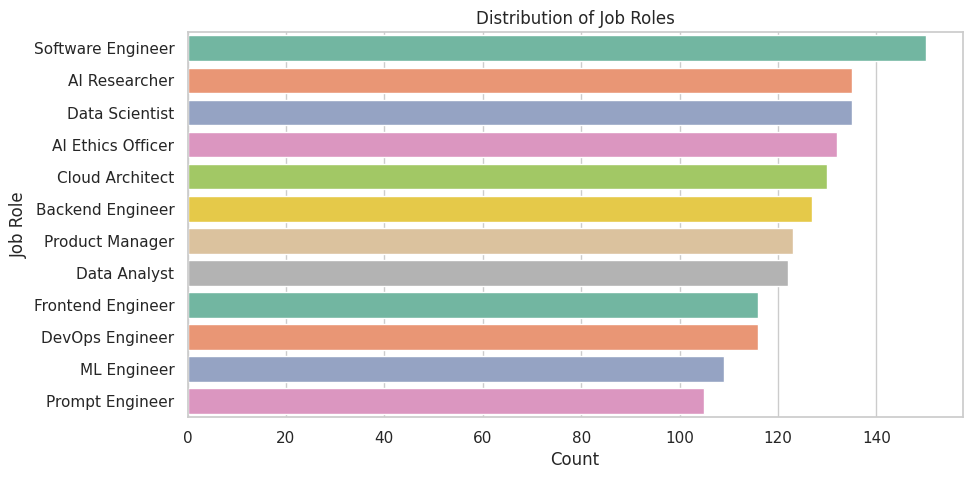

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(y='job_role', data=df, palette='Set2', order=df['job_role'].value_counts().index)
plt.title("Distribution of Job Roles")
plt.xlabel("Count")
plt.ylabel("Job Role")
plt.show()

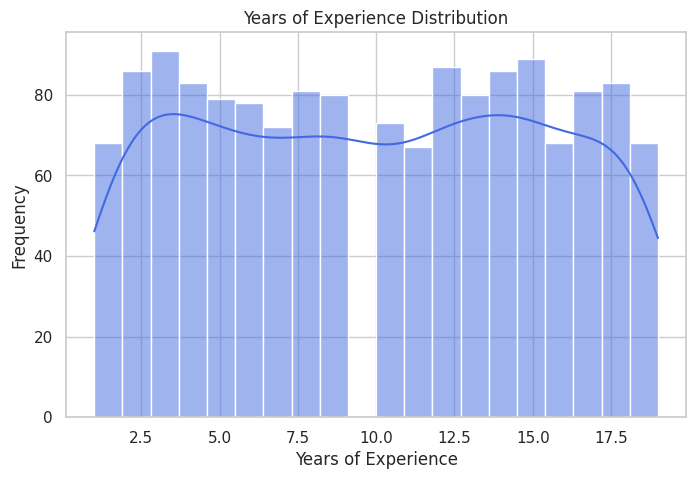

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['years_experience'], bins=20, kde=True, color='royalblue')
plt.title("Years of Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Frequency")
plt.show()

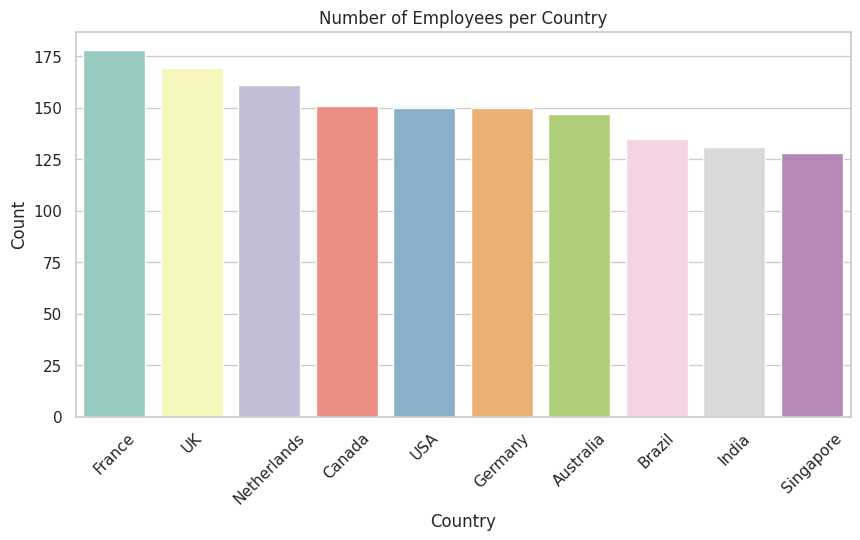

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='country', data=df, palette='Set3', order=df['country'].value_counts().index)
plt.title("Number of Employees per Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

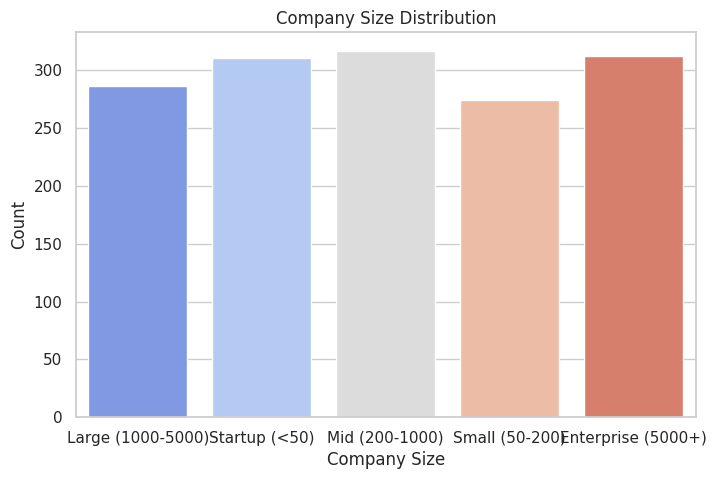

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='company_size', data=df, palette='coolwarm')
plt.title("Company Size Distribution")
plt.xlabel("Company Size")
plt.ylabel("Count")
plt.show()

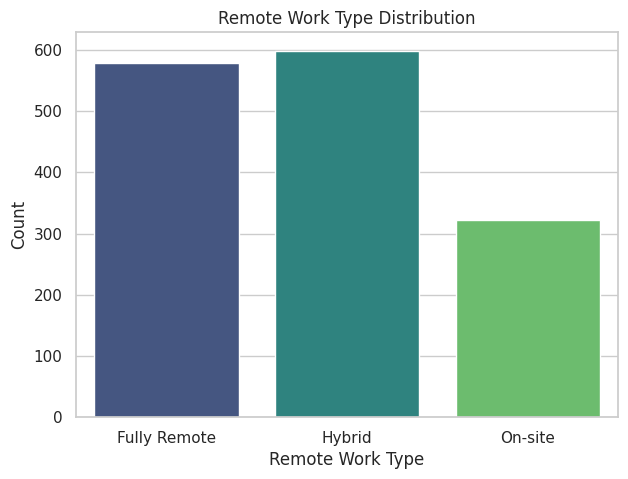

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(x='remote_work_type', data=df, palette='viridis')
plt.title("Remote Work Type Distribution")
plt.xlabel("Remote Work Type")
plt.ylabel("Count")
plt.show()

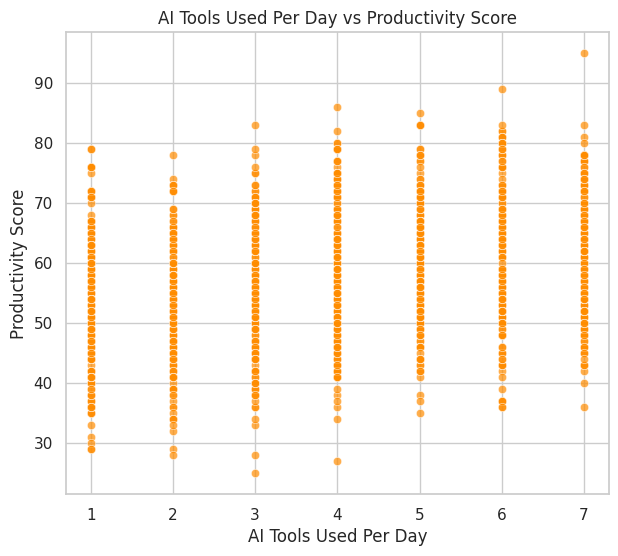

In [19]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='ai_tools_used_per_day', y='productivity_score', data=df, color='darkorange', alpha=0.7)
plt.title("AI Tools Used Per Day vs Productivity Score")
plt.xlabel("AI Tools Used Per Day")
plt.ylabel("Productivity Score")
plt.show()

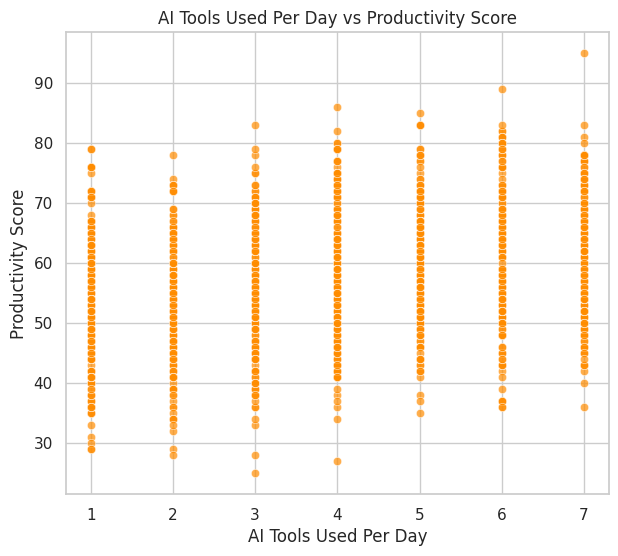

In [20]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='ai_tools_used_per_day', y='productivity_score', data=df, color='darkorange', alpha=0.7)
plt.title("AI Tools Used Per Day vs Productivity Score")
plt.xlabel("AI Tools Used Per Day")
plt.ylabel("Productivity Score")
plt.show()

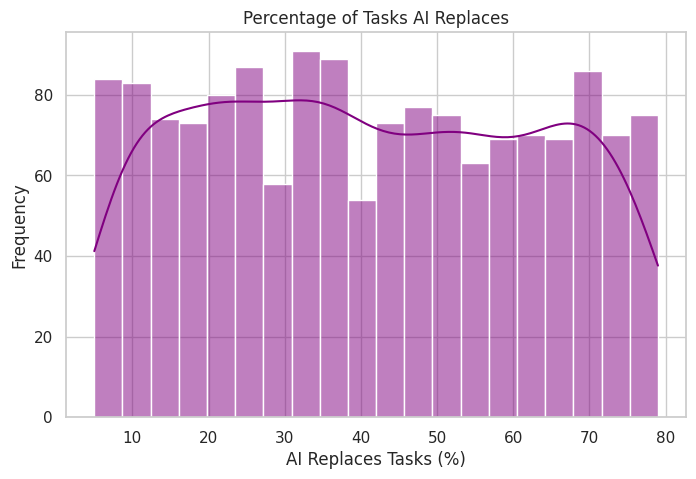

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['ai_replaces_my_tasks_pct'], bins=20, kde=True, color='purple')
plt.title("Percentage of Tasks AI Replaces")
plt.xlabel("AI Replaces Tasks (%)")
plt.ylabel("Frequency")
plt.show()

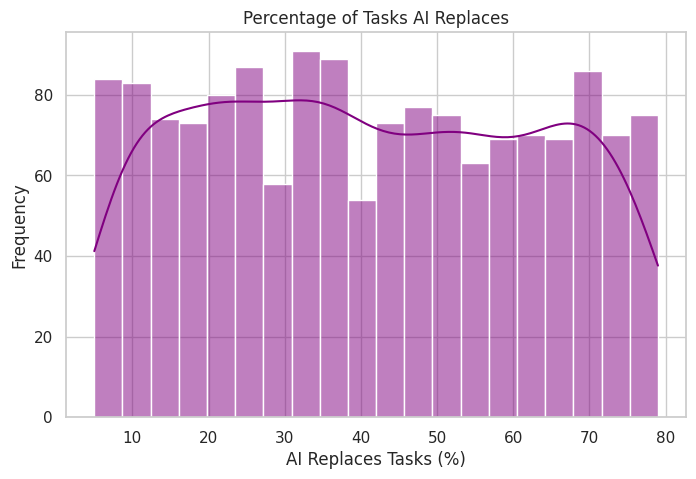

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['ai_replaces_my_tasks_pct'], bins=20, kde=True, color='purple')
plt.title("Percentage of Tasks AI Replaces")
plt.xlabel("AI Replaces Tasks (%)")
plt.ylabel("Frequency")
plt.show()

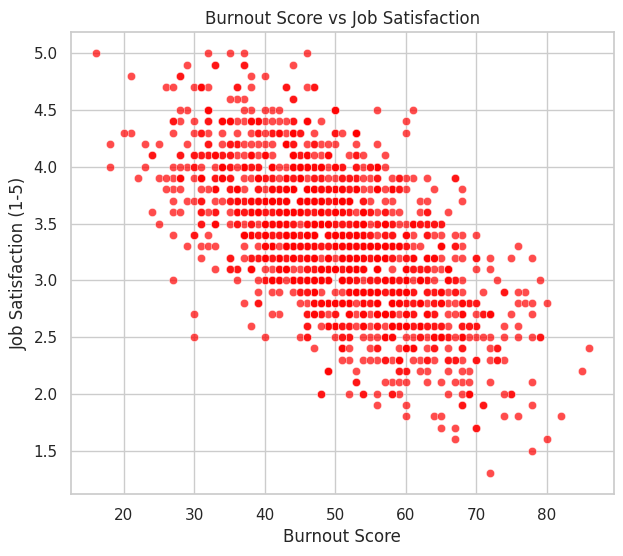

In [23]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='burnout_score', y='job_satisfaction_1_5', data=df, color='red', alpha=0.7)
plt.title("Burnout Score vs Job Satisfaction")
plt.xlabel("Burnout Score")
plt.ylabel("Job Satisfaction (1-5)")
plt.show()

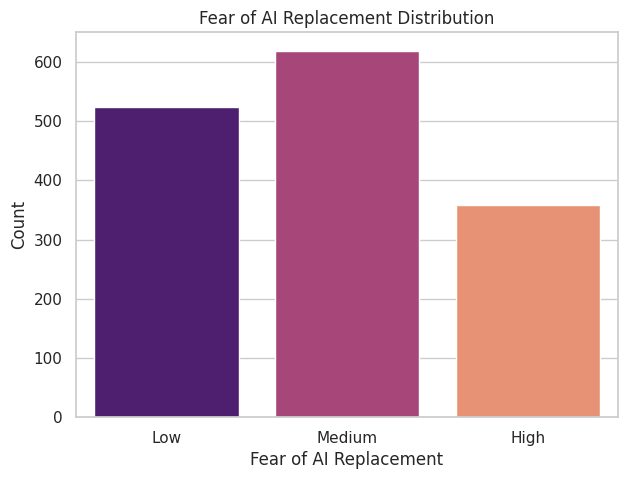

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(x='fear_of_ai_replacement', data=df, palette='magma')
plt.title("Fear of AI Replacement Distribution")
plt.xlabel("Fear of AI Replacement")
plt.ylabel("Count")
plt.show()

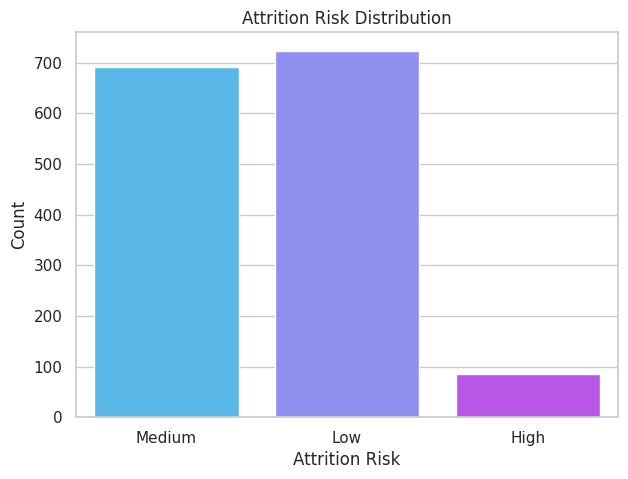

In [25]:
plt.figure(figsize=(7,5))
sns.countplot(x='attrition_risk', data=df, palette='cool')
plt.title("Attrition Risk Distribution")
plt.xlabel("Attrition Risk")
plt.ylabel("Count")
plt.show()

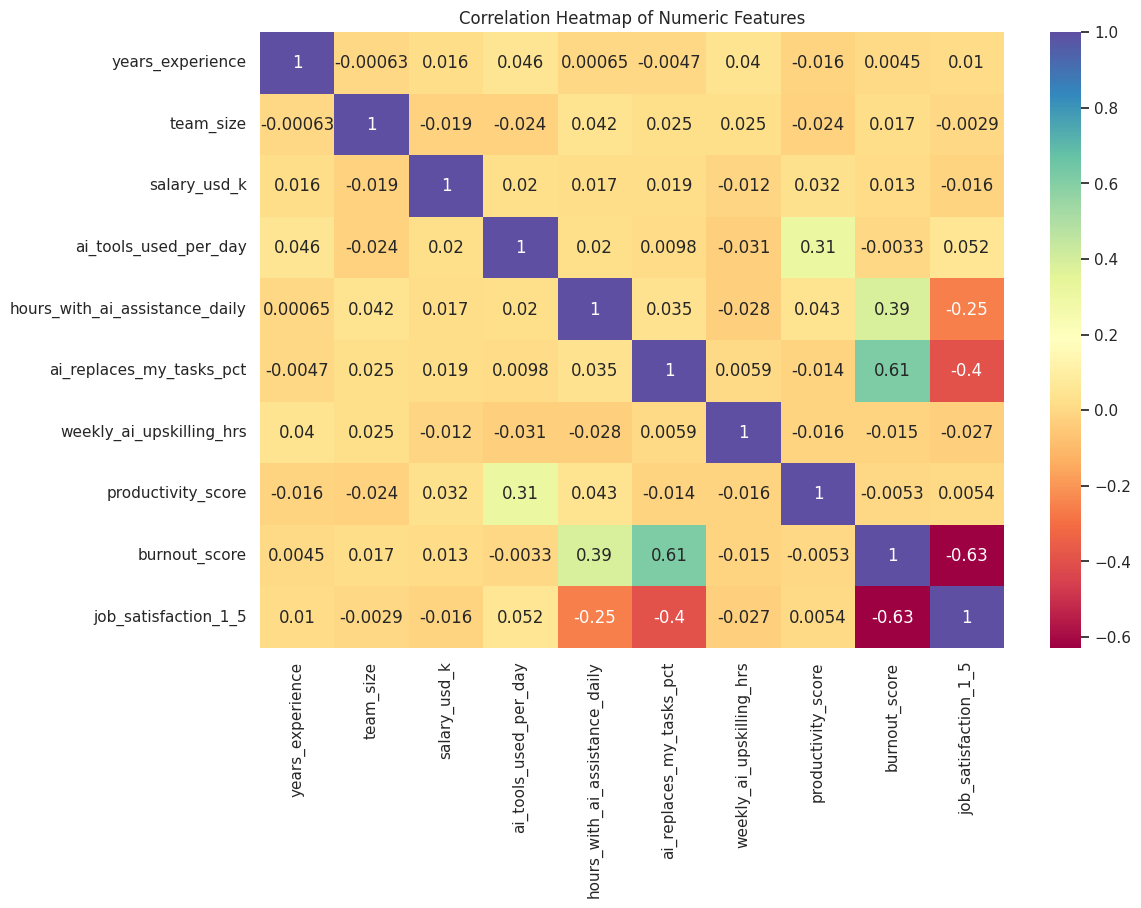

In [26]:
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include=['float64','int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Spectral')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Feature engineering

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [28]:
df_model = df.drop(columns=['employee_id'])

# Encode all categorical columns
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop('attrition_risk', axis=1)
y = df_model['attrition_risk']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}


In [33]:
# Binarize y_test inside the loop for safety
from sklearn.preprocessing import label_binarize

# Ensure y_test is available
classes = np.unique(y)
y_bin = label_binarize(y_test, classes=classes)
n_classes = y_bin.shape[1]

Model: Logistic Regression
Accuracy: 81.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.86      0.88      0.87       145
           2       0.77      0.84      0.81       138

    accuracy                           0.81       300
   macro avg       0.54      0.57      0.56       300
weighted avg       0.77      0.81      0.79       300



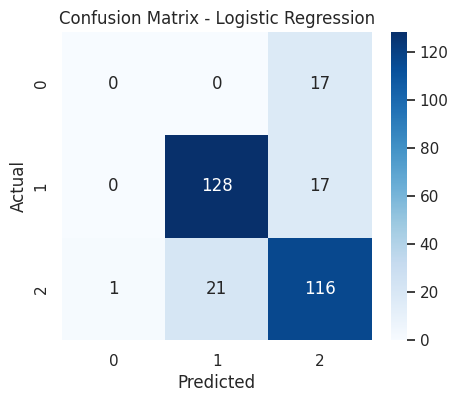

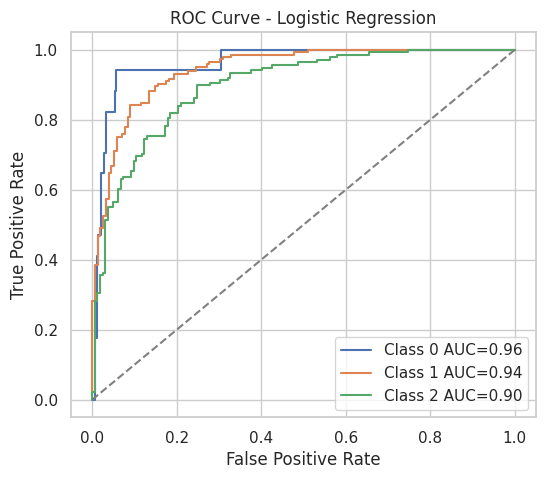

Model: Random Forest
Accuracy: 86.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.24      0.35        17
           1       0.91      0.90      0.91       145
           2       0.82      0.89      0.85       138

    accuracy                           0.86       300
   macro avg       0.80      0.68      0.70       300
weighted avg       0.85      0.86      0.85       300



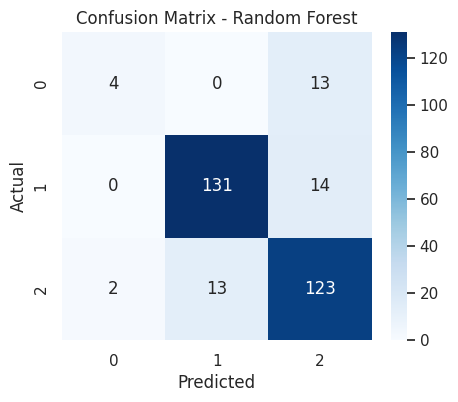

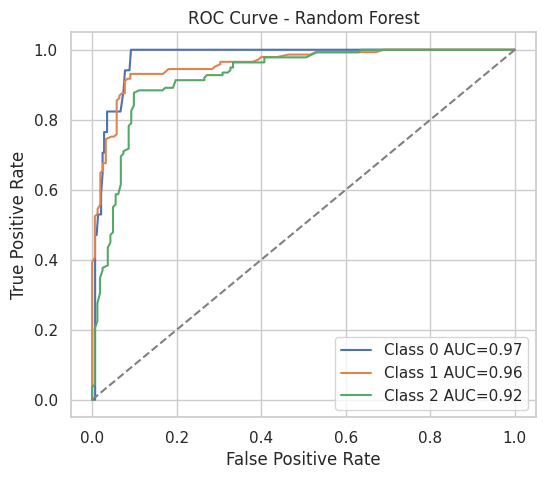

Model: Decision Tree
Accuracy: 80.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.53      0.49        17
           1       0.88      0.83      0.85       145
           2       0.77      0.80      0.79       138

    accuracy                           0.80       300
   macro avg       0.70      0.72      0.71       300
weighted avg       0.81      0.80      0.80       300



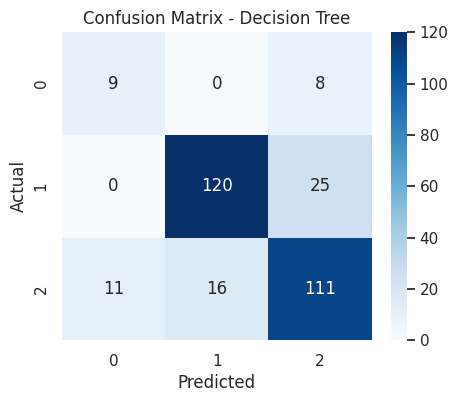

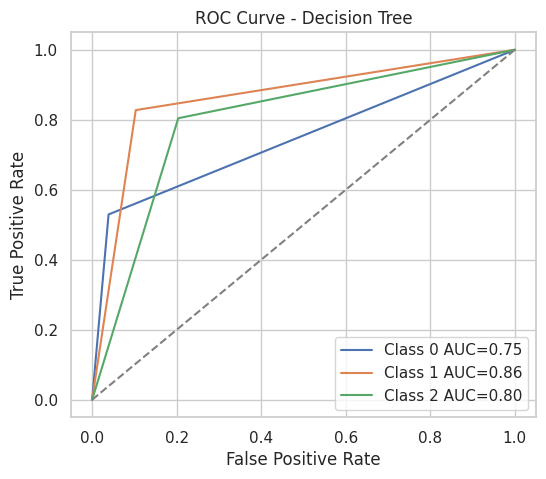

Model: SVM
Accuracy: 81.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.06      0.10        17
           1       0.90      0.83      0.86       145
           2       0.75      0.88      0.81       138

    accuracy                           0.81       300
   macro avg       0.66      0.59      0.59       300
weighted avg       0.80      0.81      0.80       300



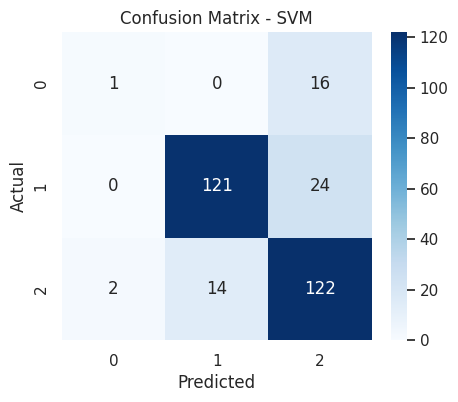

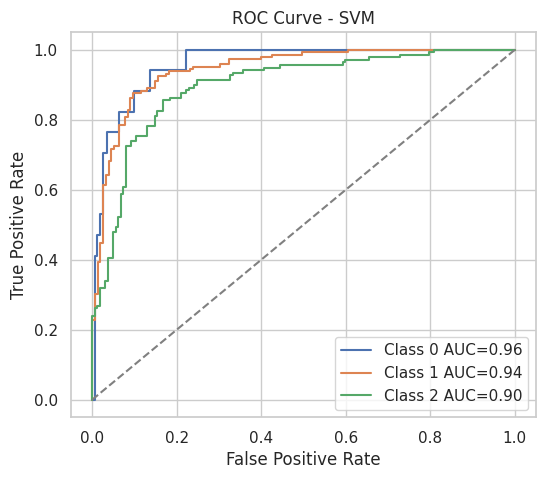

Model: Naive Bayes
Accuracy: 82.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.35      0.48        17
           1       0.87      0.86      0.86       145
           2       0.79      0.86      0.82       138

    accuracy                           0.83       300
   macro avg       0.80      0.69      0.72       300
weighted avg       0.83      0.83      0.82       300



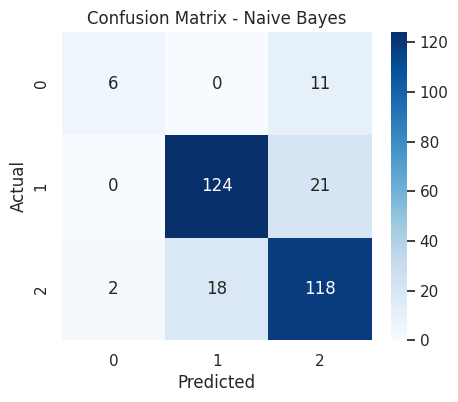

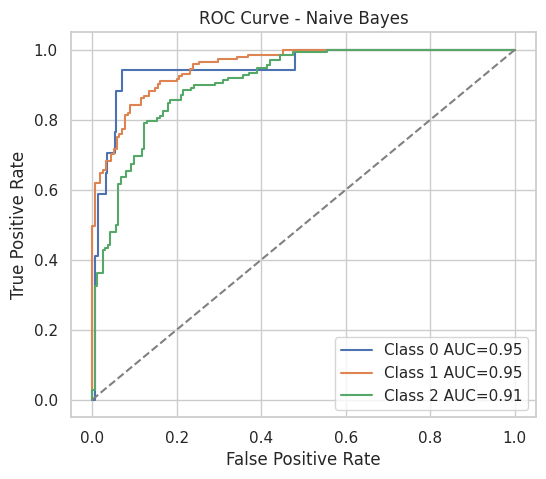

Model: KNN
Accuracy: 72.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.06      0.08        17
           1       0.76      0.83      0.79       145
           2       0.71      0.69      0.70       138

    accuracy                           0.72       300
   macro avg       0.54      0.53      0.53       300
weighted avg       0.70      0.72      0.71       300



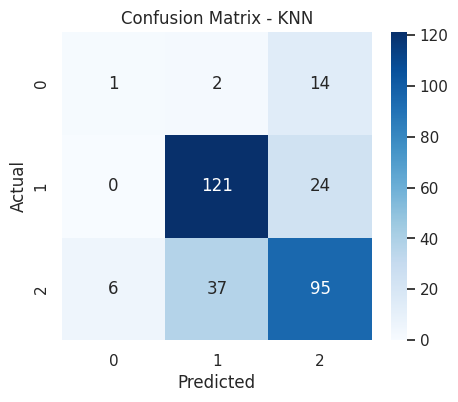

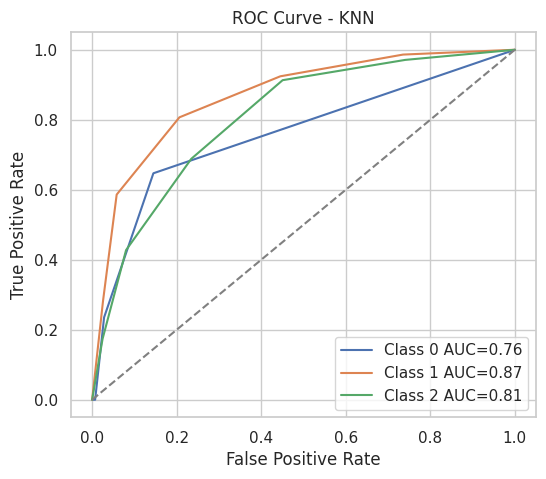

In [34]:
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred) * 100
    print("="*60)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.2f}%")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve (One-vs-Rest)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:  # For SVM
        y_prob = model.decision_function(X_test)
        if y_prob.ndim == 1:
            y_prob = np.vstack([1 - y_prob, y_prob]).T
    
    plt.figure(figsize=(6,5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_score = roc_auc_score(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} AUC={auc_score:.2f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!!